In [1]:
from scr.qsvdd_core.circuits import QSVDDCircuit
import numpy as np
from qiskit import transpile, QuantumCircuit
from qclib.util import get_cnot_count

In [2]:
n_qubits = 5
amplitudes = np.random.rand(2**n_qubits)
amplitudes /= np.linalg.norm(amplitudes)
params = np.random.rand(9*n_qubits)

In [3]:
q_circuit = QSVDDCircuit(n_qubits)
ucge_sp = q_circuit.feature_mapping(amplitudes, method="ucge")
qiskit_sp = q_circuit.feature_mapping(amplitudes, method="qiskit")
dc_sp = q_circuit.feature_mapping(amplitudes, method="dcsp")

ucge_transpiled = transpile(ucge_sp, basis_gates=['u', 'cx'])
qiskit_transpiled = transpile(qiskit_sp, basis_gates=['u', 'cx'])
dcsp_transpiled = transpile(dc_sp, basis_gates=['u', 'cx'])

print(
    'the Qiskit FM has %d CNOTs and depth of %d\n'
    'the ucge FM has %d CNOTs and depth of %d\n'
    'the dcsp FM has %d CNOTs and depth of %d'
    %(
        get_cnot_count(qiskit_transpiled), qiskit_transpiled.depth(),
        get_cnot_count(ucge_transpiled), ucge_transpiled.depth(),
        ucge_transpiled.depth(), dcsp_transpiled.depth(),
    )
)

the Qiskit FM has 26 CNOTs and depth of 53
the ucge FM has 26 CNOTs and depth of 53
the dcsp FM has 53 CNOTs and depth of 93


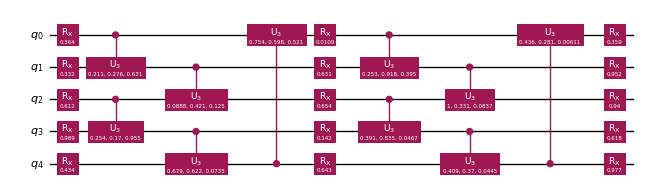

In [4]:
qc_ansatz = q_circuit.ansatz(params)
qc_ansatz.draw('mpl', scale=.5, fold=-1)

the ansatz_circuit has 20 CNOTs and depth of 21


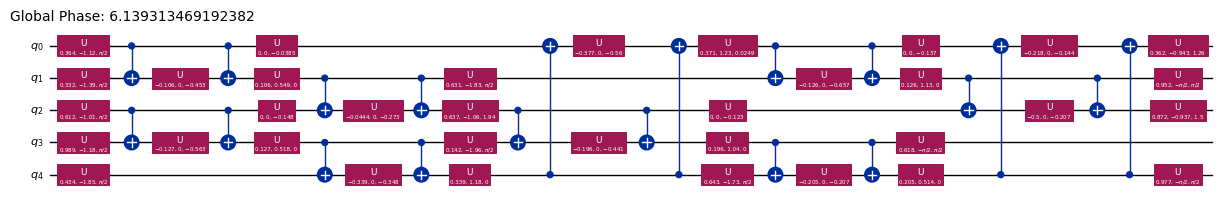

In [5]:
qc_ansatz_transpiled= transpile(qc_ansatz, basis_gates=['u', 'cx'])

print(
    'the ansatz_circuit has %d CNOTs and depth of %d'
    %(get_cnot_count(qc_ansatz_transpiled), qc_ansatz_transpiled.depth())
)

qc_ansatz_transpiled.draw('mpl', scale=.5, fold=-1)